In [ ]:
path_project = "d:/OneDrive - Universität Würzburg/Promotion/Skripts/cell_model/"
include(project_path*"model.jl")
using CSV
using DataFrames
using StatsPlots
using JLD2

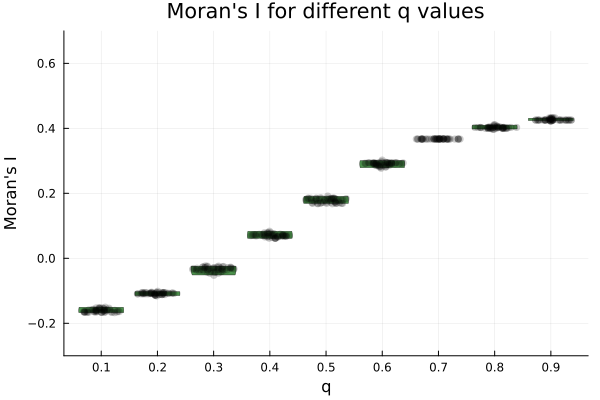

D:/data/paper25/ss_3d/fast/q/q/


In [ ]:

par = "q"
#values = Int.(range(1,10,10))
values = range(0.1,step=0.1,stop=0.9)
replicates = 50
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")



#full_path = "D:/data/paper25/ss/test_300_cells/q/q/"

#full_path =  "D:/data/paper25/cell_div/innit_50/q/q/"

#full_path =  "D:/data/paper25/set_to_zero/q/q/"
#full_path = "D:/data/paper25/set_to_zero/tol_5/q/q/"
full_path = "D:/data/paper25/ss_3d/fast/q/q/"


println(full_path)
q_df = DataFrame()
for k in values
    #str_k = replace(string(k), "." => "_")
    str_k = string(k)
    morans = zeros(Union{Missing,Float64},replicates)
    for i in range(1,replicates)
        try
        test_ms = deserialize(full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")

        # for old data: morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
        # for new data: morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
        

 
        morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
        #morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)

        catch e
            #println("Error: ", e)
            println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
            continue
        
        
        finally
            continue
        end
    end
    q_df[!, string(k)] = morans
end

for c ∈ eachcol(q_df)
    replace!(c, NaN => missing)
end



q_df_grouped = DataFrames.stack(q_df)
dropmissing!(q_df_grouped)

#q_df_grouped[!,:variable] = parse.(Int,q_df_grouped[:,:variable])
p = plot(xdiscrete_values=names(q_df),ylimits = (-0.3,0.7))
@df q_df_grouped violin!(:variable, :value, title = "Moran's I for different "*par*" values", xlabel = par, ylabel = "Moran's I", legend = false, color = "darkgreen",linewidth = 0.5,alpha=0.7)
@df q_df_grouped dotplot!(:variable, :value, group = :variable,color = "black",linewidth = 0.2,alpha=0.2)
display(p)
#savefig(p, full_path*par*"_steps_0_1_violin.svg")


## Rounding tolerance plots

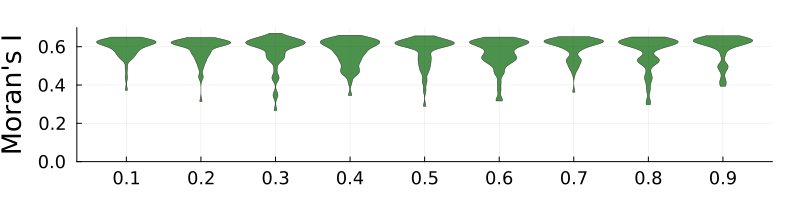

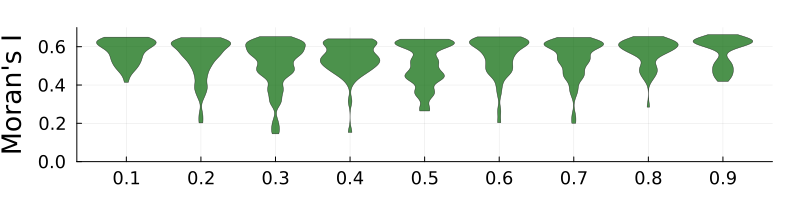

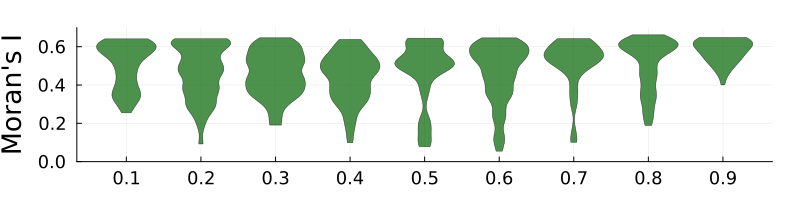

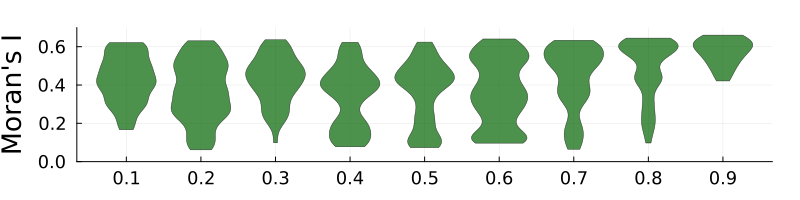

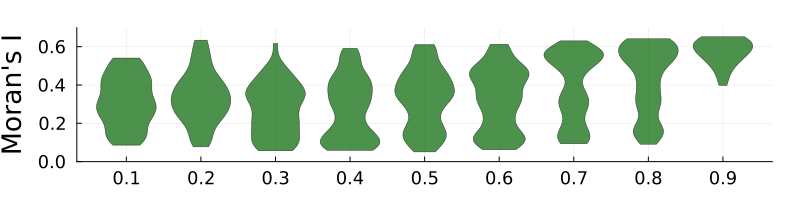

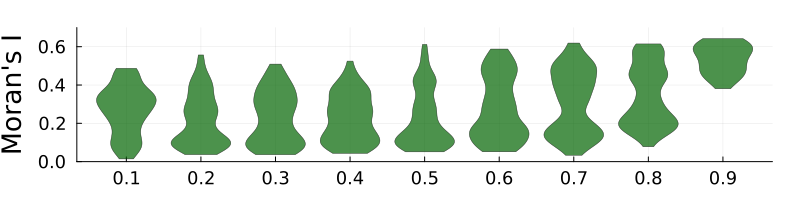

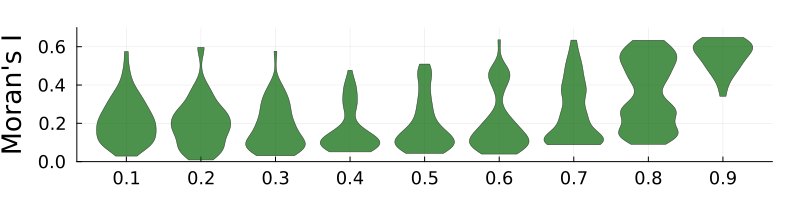

In [27]:

par = "q"
values = range(4,10)
replicates = 50
simulation_type_tup = read_sim_options(path*"simulation_options.txt")

x_names = ["10-"*string(x) for x in values]
path_part_1 = "D:/data/paper25/set_to_zero/tol_"
path_part_2 = "/q/q/"

outpath = "D:/data/plots/paper/cut_off/"


for k in values
    str_k = string(k)

    q_df = DataFrame()
    for q_value in range(0.1,step=0.1,stop=0.9)
        #str_k = replace(string(k), "." => "_")


        full_path = path_part_1 *string(k)*path_part_2
        morans = zeros(Union{Missing,Float64},replicates)
        for i in range(1,replicates)
            try
            test_ms = deserialize(full_path*"q_"*string(q_value)*"_rep_"*string(i)*".jld2")

            # for old data: morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
            # for new data: morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
            

    
            #morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
            morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)

            catch e
                #println("Error: ", e)
                println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
                continue
            
            
            finally
                continue
            end
        end
        q_df[!, string(q_value)] = morans
    end

    for c ∈ eachcol(q_df)
        replace!(c, NaN => missing)
    end



    q_df_grouped = DataFrames.stack(q_df)
    dropmissing!(q_df_grouped)
    #q_df_grouped[!,:variable] = parse.(Int,q_df_grouped[:,:variable])
    #p = plot(xdiscrete_values=names(q_df),size=(650,400),margin=5mm,ylims=(-0.35,0.7),xticks=(0.5:6.5,x_names))
    p = plot(xdiscrete_values=names(q_df),size=(800,200),margin=5mm,ylims=(0,0.7),yticks=0.0:0.2:0.6,
        xtickfontsize=12,ytickfontsize=12,xguidefontsize=18,yguidefontsize=18,legendfontsize=12)
    @df q_df_grouped violin!(:variable, :value, title = "", xlabel = "", ylabel = "Moran's I", legend = false, color = "darkgreen",linewidth = 0.5,alpha=0.7)
    #@df q_df_grouped dotplot!(:variable, :value, group = :variable,color = "black",linewidth = 0.2,alpha=0.5)
    display(p)
    savefig(p, outpath*"cut_off_"*string(k)*"_violin.svg")
    savefig(p, outpath*"cut_off_"*string(k)*"_violin.pdf")
    end

### Sorting for q and no trans:

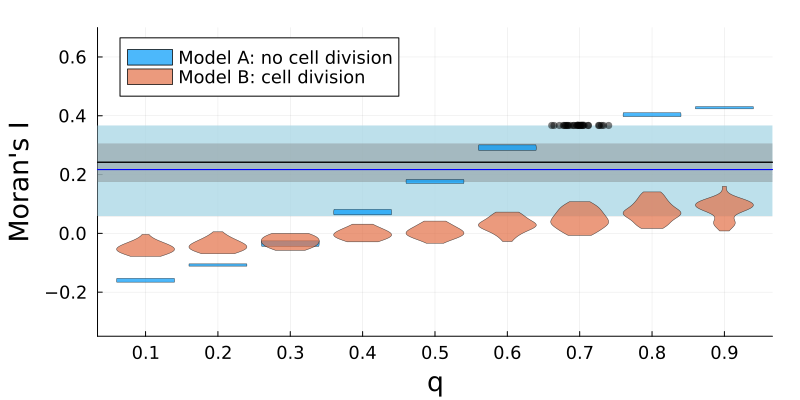

"D:\\data\\plots\\paper\\3d_no_sorting_morans_full_legend_both.pdf"

In [5]:
par = "q"
values = range(0.1,step=0.1,stop=0.9)
replicates = 30
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")


#full_path_1 = "D:/data/paper25/ss/cells_300/q/q/"
full_path_1 = "D:/data/paper25/ss_3d/fast/q/q/"
full_path_2 = "D:/data/paper25/cell_div_300/innit_50/q/q/"

path_list = [full_path_1,full_path_2]
df_list = []
for full_path in path_list
    q_df = DataFrame()
    for k in values
        #str_k = replace(string(k), "." => "_")
        str_k = string(k)
        morans = zeros(Union{Missing,Float64},replicates)
        for i in range(1,replicates)
            try
            test_ms = deserialize(full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")
            
            
            if typeof(test_ms) == Cell_struct
    
                morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
            else

                morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
            end

            catch e
                #println("Error: ", e)
                println("Could not load file: ", full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")
                continue
            
            
            finally
                continue
            end
        end
        q_df[!, string(k)] = morans
    end

    push!(df_list, q_df)
end



#q_df_grouped = DataFrames.stack(q_df)
#dropmissing!(q_df_grouped)



p = plot(xdiscrete_values=names(df_list[1]),legend = :topleft,size=(800,400),margin=5mm,ylims=(-0.35,0.7)
,xtickfontsize=12,ytickfontsize=12,xguidefontsize=18,yguidefontsize=18,legendfontsize=12)
hspan!(p,[0.367,0.059],alpha=0.8,color="lightblue",label="")
hspan!(p,[0.175,0.306],alpha=0.4,color="grey",label="")

hline!(p,[0.217 0.217], color="blue",label="")
hline!(p,[0.242 0.242], color="black",label="")


c = [palette(:tab10)[1],palette(:tab10)[2]]
labels=["Model A: no cell division","Model B: cell division","data 3"]
for i in range(1,length(df_list))
    for c ∈ eachcol(df_list[i])
        replace!(c, NaN => missing)
    end
    q_df_grouped = DataFrames.stack(df_list[i])
    dropmissing!(q_df_grouped)
    @df q_df_grouped violin!(:variable, :value, title = "", xlabel = par, ylabel = "Moran's I",label=labels[i],linewidth = 0.5,alpha=0.7,color=i)
end
##########################
full_path_1 = "D:/data/paper25/ss_3d/fast/q/q/"
q_df = DataFrame()
morans = zeros(Union{Missing,Float64},replicates)
for i in range(1,replicates)
    try
    test_ms = deserialize(full_path_1*"q_0.7_rep_"*string(i)*".jld2")
    
    
    if typeof(test_ms) == Cell_struct

        morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
    else

        morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
    end

    catch e
        #println("Error: ", e)
        println("Could not load file: ", full_path_1*"q_0.7_rep_"*string(i)*".jld2")
        continue
    
    
    finally
        continue
    end
end
q_df[!, string(0.7)] = morans
q_df_grouped = DataFrames.stack(q_df)
dropmissing!(q_df_grouped)
@df q_df_grouped dotplot!(:variable, :value, group = :variable,color = "black",linewidth = 0.2,alpha=0.5,label="")

###################

display(p)
save_path= "D:/data/plots/paper/"
savefig(p,save_path*"3d_no_sorting_morans_full_legend_both.svg")
savefig(p,save_path*"3d_no_sorting_morans_full_legend_both.pdf")



In [ ]:
@df q_df_grouped dotplot!(:variable, :value, group = :variable,color = "black",linewidth = 0.2,alpha=0.2)

## Sorting with and without transcription

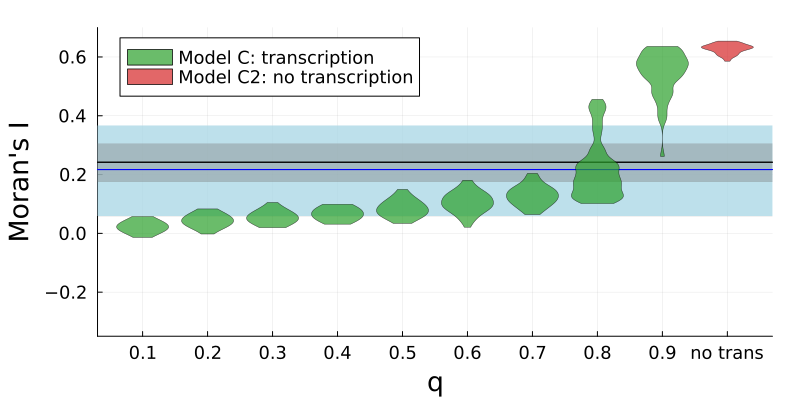

D:/data/paper25/sorting_new/q/q/


"D:\\data\\plots\\paper\\sorting_morans_full_legend_both.pdf"

In [4]:

par = "q"
values = range(0.1,step=0.1,stop=0.9)
replicates = 45
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")
df_list = []


full_path = "D:/data/paper25/sorting_new/q/q/"
println(full_path)
q_df = DataFrame()
for k in values

    str_k = string(k)
    morans = zeros(Union{Missing,Float64},replicates)
    for i in range(1,replicates)
        try
        test_ms = deserialize(full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")

        morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)

        catch e

            println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
            continue
        
        
        finally
            continue
        end
    end
    q_df[!, string(k)] = morans
end

for c ∈ eachcol(q_df)
    replace!(c, NaN => missing)
end


push!(df_list,q_df)

#force_path = "D:/data/sorting/forces/beta/beta/beta_1.0_rep_"

force_path = "D:/data/paper25/beta/300_cells/beta/beta/beta_1.0_rep_"
a = deserialize("D:/data/sorting/forces/beta/beta/beta_1.0_rep_1.jld2")[1]

replicates = 50
calculate_moran_index(a, simulation_type_tup)

morans = zeros(Union{Missing,Float64},replicates)
for i in range(1,replicates)
    test_ms = deserialize(force_path*string(i)*".jld2")

    morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
    
end

b = DataFrame(Dict("no trans" => morans))

push!(df_list,b)

p = plot(xdiscrete_values=vcat(names(df_list[1]),names(b)),legend = :topleft,size=(800,400),margin=5mm,ylims=(-0.35,0.70)
    ,xtickfontsize=12,ytickfontsize=12,xguidefontsize=18,yguidefontsize=18,legendfontsize=12)
hspan!(p,[0.367,0.059],alpha=0.8,color="lightblue",label="")
hspan!(p,[0.175,0.306],alpha=0.4,color="grey",label="")

hline!(p,[0.217 0.217], color="blue",label="")
hline!(p,[0.242 0.242], color="black",label="")

c = [palette(:tab10)[3],palette(:tab10)[4]]
labels=["Model C: transcription","Model C2: no transcription","data 3"]
for i in range(1,length(df_list))
    for c ∈ eachcol(df_list[i])
        replace!(c, NaN => missing)
    end
    q_df_grouped = DataFrames.stack(df_list[i])
    dropmissing!(q_df_grouped)
    @df q_df_grouped violin!(:variable, :value, title = "", xlabel = par, ylabel = "Moran's I",label=labels[i],linewidth = 0.5,alpha=0.7,color=c[i])
end

display(p)
save_path= "D:/data/plots/paper/"
savefig(p,save_path*"sorting_morans_full_legend_both.svg")
savefig(p,save_path*"sorting_morans_full_legend_both.pdf")

In [50]:

force_path = "D:/data/paper25/beta/300_cells/beta/beta/beta_1.0_rep_"
a = deserialize("D:/data/paper25/beta/300_cells/beta/beta/beta_1.0_rep_1.jld2")[1]

replicates = 40
a_m = calculate_moran_index(a, simulation_type_tup)

morans = zeros(Union{Missing,Float64},replicates)
for i in range(1,replicates)
    test_ms = deserialize(force_path*string(i)*".jld2")

    morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
    
end
morans

40-element Vector{Union{Missing, Float64}}:
 0.6364834221977081
 0.6109251451293229
 0.6411140393040843
 0.6525145574094106
 0.6344008297360905
 0.6354686938783808
 0.6307604336130662
 0.6401970115887551
 0.6491234208248905
 0.6175955850940493
 ⋮
 0.6160624827911932
 0.6293514437012808
 0.6352521650534895
 0.6034684587036634
 0.6348169242111046
 0.6459928276000654
 0.628212477466834
 0.6261001554369697
 0.6422572557411381

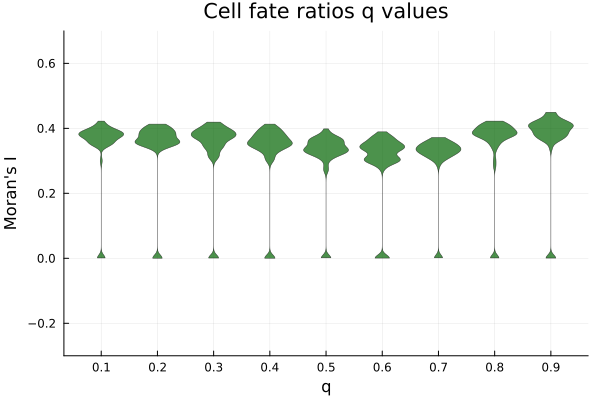

In [41]:

par = "q"
#values = Int.(range(1,10,10))
values = range(0.1,step=0.1,stop=0.9)
replicates = 50
simulation_type_tup = read_sim_options("simulation_options.txt")



#full_path = "D:/data/paper25/ss/test_300_cells/q/q/"

#full_path =  "D:/data/paper25/cell_div/innit_50/q/q/"

#full_path =  "D:/data/paper25/set_to_zero/q/q/"
full_path = "D:/data/paper25/set_to_zero/tol_10/q/q/"

full_path = "D:/data/paper25/sorting_new/q/q/"

println(full_path)
q_df = DataFrame()
for k in values
    #str_k = replace(string(k), "." => "_")
    str_k = string(k)
    ratio = zeros(Union{Missing,Float64},replicates)
    for i in range(1,replicates)
        try
        test_ms = deserialize(full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")[1]

        # for old data: morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
        # for new data: morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
        

 
        #morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
        len_test_ms_u = length(test_ms.u)
        ratio[i] = sum(test_ms.u .> test_ms.v)/len_test_ms_u

        catch e
            #println("Error: ", e)
            println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
            continue
        
        
        finally
            continue
        end
    end
    q_df[!, string(k)] = ratio
end

for c ∈ eachcol(q_df)
    replace!(c, NaN => missing)
end



q_df_grouped = DataFrames.stack(q_df)
dropmissing!(q_df_grouped)

#q_df_grouped[!,:variable] = parse.(Int,q_df_grouped[:,:variable])
p = plot(xdiscrete_values=names(q_df),ylimits = (-0.3,0.7))
@df q_df_grouped violin!(:variable, :value, title = "Cell fate ratios "*par*" values", xlabel = par, ylabel = "Moran's I", legend = false, color = "darkgreen",linewidth = 0.5,alpha=0.7)
#@df q_df_grouped dotplot!(:variable, :value, group = :variable,color = "black",linewidth = 0.2,alpha=0.5)
display(p)
#savefig(p, full_path*par*"_steps_0_1_violin.svg")

In [7]:
a = deserialize("D:/data/sorting/timecourse/super_slow/dt_div/q/q/q_0.1_rep_1.jld2")
if typeof(a) == Cell_struct

    b= calculate_moran_index(a, simulation_type_tup)
else
    b= calculate_moran_index(a[1], simulation_type_tup)
end
b

-0.016925697253566102

In [166]:

par = "beta"
#values = Int.(range(1,10,10))
values = range(0.1,step=0.1,stop=0.9)
replicates = 1
simulation_type_tup = read_sim_options("simulation_options.txt")

full_path ="D:/data/sorting/timecourse/super_slow/dt_div/beta/"


values_q = range(0.1,step=0.1,stop=0.9)
beta_values = range(1.0,step=0.1,stop=2.0)
println(full_path)
q_df = DataFrame()
for beta in beta_values
    q_list = []
    for k in values_q
        str_k = replace(string(k), "." => "_")
        #str_k = string(k)
        morans = zeros(Union{Missing,Float64},replicates)
        for i in range(1,replicates)
            try
            test_ms = deserialize(full_path*"q_"*str_k*"/beta/beta_"*string(beta)*"_rep_"*string(i)*".jld2")

            # for old data: morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
            # for new data: morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
            

    
            #morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
            morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)

            catch e
                #println("Error: ", e)
                println("Could not load file: ", full_path*"q_"*str_k*"/beta/beta_"*string(beta)*"_rep_"*string(i)*".jld2")
                continue
            
            
            finally
                continue
            end     
        end
        push!(q_list,mean(morans))
    end
    q_df[!, string(beta)] = q_list
end


D:/data/sorting/timecourse/super_slow/dt_div/beta/
Could not load file: D:/data/sorting/timecourse/super_slow/dt_div/beta/q_0_7/beta/beta_1.3_rep_1.jld2


## Heatmap for signal distance and transcription cut off

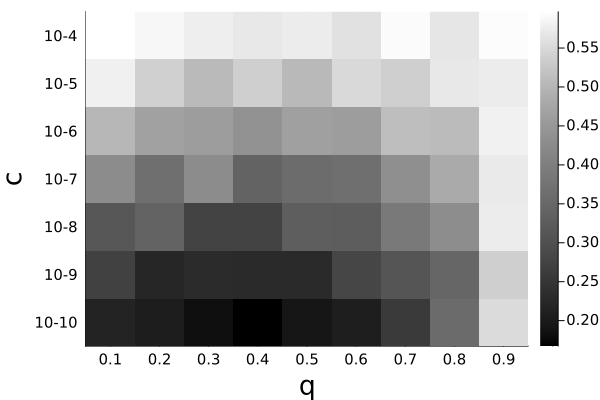

"D:\\data\\plots\\paper\\cut_off\\heatmap_gray.png"

In [3]:

par = "q"
values = range(4,10)
q_values = range(0.1,step=0.1,stop=0.9)
replicates = 50        
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")
x_names = ["10-"*string(x) for x in values]
path_part_1 = "D:/data/paper25/set_to_zero/tol_"
path_part_2 = "/q/q/"

outpath = "D:/data/plots/paper/cut_off/"
q_df = DataFrame()
for q_value in q_values
    q_list = []


    for k in values
     
        str_k = string(k)

        full_path = path_part_1 *string(k)*path_part_2
        morans = zeros(Union{Missing,Float64},replicates)
        for i in range(1,replicates)
            try
            test_ms = deserialize(full_path*"q_"*string(q_value)*"_rep_"*string(i)*".jld2")
    

            morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)

            catch e
                #println("Error: ", e)
                println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
                continue
            
            
            finally
                continue
            end
        end
        push!(q_list,mean(morans))
    end
    q_df[!, string(q_value)] = q_list
end


    q_df_grouped = DataFrames.stack(q_df)
    dropmissing!(q_df_grouped)

m = heatmap(reverse(Matrix(q_df),dims=1),title = "",xlabel="q",ylabel="c",colorbar_title="",xticks=(1:11,string.(q_values)),yticks=(1:7,reverse(x_names))
,xtickfontsize=10,ytickfontsize=10,xguidefontsize=18,yguidefontsize=18,legendfontsize=10,titlefontsize=18,c= :grayC)
display(m)
savefig(m,outpath*"heatmap_gray.svg")
savefig(m,outpath*"heatmap_gray.pdf")
savefig(m,outpath*"heatmap_gray.png")

## 3D Plots

In [ ]:
lim = 2
#path = "D:/data/signal_modes/ss_1/donator/cell_div_slow/eps_N/"
#path = "D:/data/sorting/donator/cells_300/q/q/"

path = "D:/data/paper25/sorting_new/q/q/"
outfolder = "D:/data/paper25/sorting_new/"

values = range(-6.1,step=-0.1,stop=-7.75)

reps = range(1,20)
for rep in reps
    plot_all = []
    for s in ["1","5","9"]
        full_path = path *"q_0."*s*"_rep_"*string(rep)*".jld2"
        

        data = deserialize(full_path)[1]
        data = data
        test = DataFrame(data.xy, :auto)
        test[!,:index] = range(1,length(test.x1))
        # create 4 equally spaced bins between the minimum and maximum values of the x2 column
        bins = range(minimum(test.x2), stop=maximum(test.x2), length=6)

        plot_list = []   

        filtered_test = filter(row ->  bins[3] <= row.x3 < bins[3+1], test)
        a = scatter(filtered_test.x1,filtered_test.x2,filtered_test.x3,label="",xlabel="",ylabel="",zlabel="",aspect_ratio=:equal,marker_z=data.u[filtered_test.index],
        clim = (0, 0.1),ylim =(-lim,lim),xlim=(-lim,lim),zlim=(-lim,lim),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true))
        push!(plot_list,a)

        push!(plot_list,scatter(test.x1,test.x2,test.x3,label="",xlabel="",ylabel="",zlabel="",title="q = 0."*s,aspect_ratio=:equal,marker_z=data.u,
            clim = (0, 0.1),ylim =(-lim,lim),xlim=(-lim,lim),zlim=(-lim,lim),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true)))

        reverse!(plot_list)
        p = plot(plot_list...,size=(400,800),layout=(2,1))
        push!(plot_all,p)
    end

    p_all = plot(plot_all...,size=(1200,800),layout=(1,3),plot_title = "Sorting; 300 cells; rep="*string(rep))
    savefig(p_all,outfolder*"_rep_"*string(rep)*".svg")
    savefig(p_all,outfolder*"_rep_"*string(rep)*".png")
end


In [13]:

simulation_type_tup = (

    # simulation steps:

    physics = true,
    brownian = true,
    transcr = true,
    cell_division = true,
    affinity = true,
    anim = false,
    save_data = true,
    track_progress = false,
    set_to_zero = true,

    # specification of which functions to use:

    # physics: 
        # cell devision, can be random_angle_cell_devision,  non_random_cell_devision
    cell_div_func = random_angle_cell_devision,
    func_orth = false,
    tf_split = true,
    
    # transcription:
        #signalling: can be nearest_neighbour (signalling_nn), distance_based (signalling_distance)
    sign_func = signalling_distance,
    check_distance = true,
    topography = false,

    # animation:
        #scatter plot is default
    draw_edges = true,
    draw_radius = false,

    # simulate to specific number of cells?
    cell_number_check = true,
    donator = true

)
### Paramater ###
#par = CSV.File("standard_parameter.csv") |> Dict
par = CSV.File("new_parameter.csv") |> Dict
par["max_cells"] = 300
par["q"] = 0.9
par["k"] = 0.1
par["save_intervall"] = 100
### Time ###
time_ss = Time_struct(500,100)

### Initial conditions 2d ###
"""
cells_dict = Dict(
    "xy" => ([-0.1 0; 0.1 0; 0.05 0.05]),
    "r" => [0.4, 0.5, 0.7],
    "u" => [0.1, 0.1,0.1],
    "v" => [0.1, 0.1,0.1],
)
"""
# init cells for gamma = 1

cells_dict = Dict(
    "xy" => ([-0.1 0; 0.1 0; 0.05 0.05]),
    "r" => [0.4, 0.5, 0.7],
    "u" => [1.0, 1.0,1.0],
    "v" => [1.0, 1.0,1.0],
)

###  Inititial conditions 3d ###
"""
cells_dict = Dict(
    "xy" => ([-0.1 0 0.3; 0.1 0 0.3; 0.05 0.05 0.3; 0.2 0.2 0.2; -0.2 -0.2 -0.2]),
    "r" => [0.6, 0.6, 0.6, 0.6, 0.6],
    "u" => [0.1, 0.1,0.1, 0.1, 0.1],
    "v" => [0.1, 0.1,0.1, 0.1, 0.1],
)
"""
# init cells for gamma = 1

cells_dict = Dict(
    "xy" => ([-0.1 0 0.3; 0.1 0 0.3; 0.05 0.05 0.3; 0.2 0.2 0.2; -0.2 -0.2 -0.2]),
    "r" => [0.6, 0.6, 0.6, 0.6, 0.6],
    "u" => [0.8, 0.8,0.8,0.8,0.8],
    "v" => [0.8,0.8,0.8,0.8,0.8],
)

cell_ms = Cell_struct(cells_dict)
### time course data ###
names = (:xy, :r, :u, :v, :s)
data_tup = create_data_tup(names)


### simulation ###
cell_ms,data_tup = run_sim_3d(cell_ms,time_ss,par,data_tup,simulation_type_tup)
#cell_ms,data_tup = run_sim(cell_ms,time_ss,par,data_tup,simulation_type_tup)
println(length(cell_ms.r))

300


In [26]:
using ColorSchemes

folder = "D:/data/paper25/ss/cells_300/q/q/"
folder = "D:/data/paper25/ss/test_300_cells/q/q/"

simulation_type_tup = read_sim_options(folder*"sim_type.txt")
cell_ms = deserialize(folder*"q_0.1_rep_3.jld2")

data = cell_ms
println(length(data.u))

test = DataFrame(data.xy, :auto)
# create 4 equally spaced bins between the minimum and maximum values of the x2 column
bins = range(minimum(test.x2), stop=maximum(test.x2), length=6)

plot_list = []   
for i in 3
 
    filtered_test = filter(row ->  bins[i] <= row.x3 < bins[i+1], test)
    a = scatter(filtered_test.x1,filtered_test.x2,filtered_test.x3,label="",xlabel="",ylabel="",zlabel="",title="part "*string(i),aspect_ratio=:equal,marker_z=data.u,
    clim = (0, 1),ylim =(-4,4),xlim=(-4,4),zlim=(-4,4),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true))
    push!(plot_list,a)
end
    push!(plot_list,scatter(test.x1,test.x2,test.x3,label="",xlabel="",ylabel="",zlabel="",title="complete",aspect_ratio=:equal,marker_z=data.u,
    clim = (0, 1),ylim =(-4,4),xlim=(-4,4),zlim=(-4,4),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true)))
p = plot(reverse(plot_list)...,size=(500,800),layout=(2,1),plot_title = "q=0.1; Moran's I: "*string(round(calculate_moran_index(cell_ms,simulation_type_tup),digits=2)))

display(p)

292


ArgumentError: ArgumentError: column name "x3" not found in the data frame; existing most similar names are: "x1" and "x2"

In [25]:
folder = "D:/data/paper25/ss/cells_300/q/q/"

simulation_type_tup = read_sim_options(folder*"sim_type.txt")
cell_ms = deserialize(folder*"q_0.1_rep_3.jld2")

data = cell_ms
data.xy

292×2 Matrix{Float64}:
 -0.189711  -2.92466
  3.91697   -0.0722996
  1.9789     1.41361
 -5.62377    1.89269
  0.561861  -4.6611
 -4.01039    1.52236
  3.6855     1.30455
 -0.161833   2.77336
 -0.111218  -1.69479
 -3.61518   -3.29956
  ⋮         
 -1.27196    0.0148391
 -4.43758   -3.08746
 -0.973994  -5.85177
 -1.27353    4.14648
  1.85326   -3.79074
  0.159892  -4.90984
 -2.33261   -3.68848
  0.598345  -4.1772
 -4.71723   -1.37092

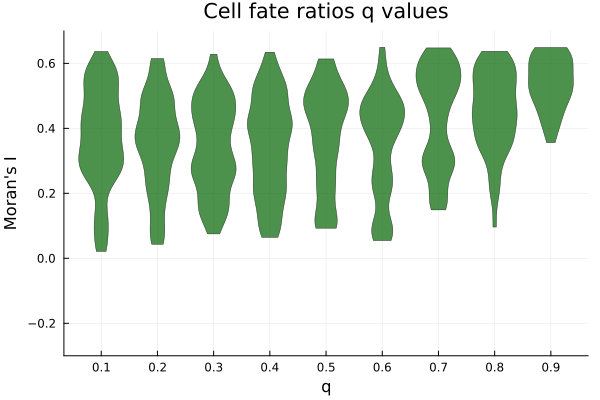

D:/data/paper25/cell_div_300/sorting/timecourse/q/q/


In [5]:

par = "q"
#values = Int.(range(1,10,10))
values = range(0.1,step=0.1,stop=0.9)
replicates = 50
simulation_type_tup = read_sim_options("simulation_options.txt")



#full_path = "D:/data/paper25/ss/test_300_cells/q/q/"

full_path = "D:/data/paper25/cell_div_300/sorting/timecourse/q/q/"

println(full_path)
q_df = DataFrame()
for k in values
    #str_k = replace(string(k), "." => "_")
    str_k = string(k)
    morans = zeros(Union{Missing,Float64},replicates)
    for i in range(1,replicates)
        try
        #println(full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
        test_ms = deserialize(full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")[1]
    
        # for old data: morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
        # for new data: morans[i] = calculate_moran_index(test_ms[1], simulation_type_tup)
        
        morans[i] = calculate_moran_index(test_ms, simulation_type_tup)
        catch e
            #println("Error: ", e)
            println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
            continue
        
 
        
        #len_test_ms_u = length(test_ms.u)
        #ratio[i] = sum(test_ms.u .> test_ms.v)/len_test_ms_u


        finally
            continue
        end
    end
    q_df[!, string(k)] = morans
end

for c ∈ eachcol(q_df)
    replace!(c, NaN => missing)
end



q_df_grouped = DataFrames.stack(q_df)
dropmissing!(q_df_grouped)

#q_df_grouped[!,:variable] = parse.(Int,q_df_grouped[:,:variable])
p = plot(xdiscrete_values=names(q_df),ylimits = (-0.3,0.7))
@df q_df_grouped violin!(:variable, :value, title = "Cell fate ratios "*par*" values", xlabel = par, ylabel = "Moran's I", legend = false, color = "darkgreen",linewidth = 0.5,alpha=0.7)
#@df q_df_grouped dotplot!(:variable, :value, group = :variable,color = "black",linewidth = 0.2,alpha=0.5)
display(p)
#savefig(p, full_path*par*"_steps_0_1_violin.svg")

In [5]:
test_ms = deserialize("D:/data/paper25/cell_div_300/sorting/timecourse/q/q/q_0.1_rep_1.jld2")[1]

Cell_struct([0.6333406938510308 -0.6971042918792784 -0.1359533849564893; 0.7910742466986703 -0.09060022846482597 0.7337820322957607; … ; -0.30628454355570717 -1.125800582598661 0.1666357722221398; -1.2050059172264869 0.5323802722445101 -0.5163673354037329], [0.9537218451670595, 0.9212821344336275, 0.9219718127532219, 0.9273197180998902, 0.92005250224009, 0.8691078319391701, 0.8691847347833148, 0.7453244444196891, 0.9465558813565843, 0.942026673178285  …  0.754573321762217, 0.7685080593878156, 0.7543269215753118, 0.7640711264042542, 0.751689387513424, 0.7581110263247488, 0.7545951762006312, 0.7568638659129993, 0.7537011807910122, 0.7493697937953708], [0.9981039680268246, 0.9981183538048929, 0.0, 0.9979517265053602, 0.0, 0.0, 0.0, 0.9977927000935379, 0.0, 0.0  …  0.9973387285676342, 0.9973561003320115, 0.0, 0.0, 0.5174067758786806, 0.9974772051265784, 0.9976602918460857, 0.997615293659096, 0.0, 0.0], [0.0, 0.0, 0.9979793200574748, 0.0, 0.9980694299650797, 0.9982717551209046, 0.9980529574

In [6]:

time_data = deserialize("D:/data/paper25/cell_div_300/sorting/timecourse/q/q/q_0.1_rep_1.jld2")[2]

(xy = Array{Float64}[[-0.4901784466740338 -0.17027140432039603 0.40620405027244527; 0.6029622437661807 -0.3341500953104069 0.4188822638565184; … ; 0.529479152288025 0.4446554847454552 -0.23325919919217702; -0.08529501645376768 -0.3191175654864003 -0.4947718772180564], [-0.49036386247620034 -0.11121707917819094 0.39185618528950533; 0.5427583175500938 -0.3530442761704481 0.47397968731742013; … ; 0.36442577313267427 0.47916094260234243 -0.14479365691151724; -0.08389343379745574 -0.3357555992130864 -0.5016480330712485], [-0.376058915833735 -0.08461795666321319 0.3395927677780856; 0.5063430004143555 -0.8573277008510786 0.4602982235294604; … ; 0.03275129864134615 -0.42422641312839493 -0.515646127211274; 0.6033797635944006 -0.07395982574921951 0.4231814624365359], [-0.39802265383649454 0.1734850626347491 0.23490850774925803; 0.39218756006005656 -0.7951940021932459 0.5537195003062431; … ; 0.7094427689211943 -0.012744738149339671 0.3614337498366779; -0.34645638206357765 -0.4850008379764269 0.40

In [8]:
push_cells_to_data!(time_data,test_ms)

In [12]:
length.(time_data.u)

72-element Vector{Int64}:
   5
   5
   6
   7
   7
   7
   7
   9
  11
  12
   ⋮
 211
 220
 229
 243
 250
 254
 274
 289
 300

In [ ]:
lim = 4
#path = "D:/data/signal_modes/ss_1/donator/cell_div_slow/eps_N/"
#path = "D:/data/sorting/donator/cells_300/q/q/"
#path = "D:/data/paper25/cell_div_300/sorting/timecourse/q/q/"
path = "D:/data/paper25/ss_3d/fast/q/q/"

outfolder = "D:/data/paper25/ss_3d/fast/"

#values = range(-6.1,step=-0.1,stop=-7.75)

reps = range(1,20)
for rep in reps
    plot_all = []
    for s in ["1","5","9"]
        full_path = path *"q_0."*s*"_rep_"*string(rep)*".jld2"
        
        

        #data = deserialize(full_path)[1] # for everything except steady_state data
        data = deserialize(full_path)
        data = data
        test = DataFrame(data.xy, :auto)
        test[!,:index] = range(1,length(test.x1))
        # create 4 equally spaced bins between the minimum and maximum values of the x2 column
        bins = range(minimum(test.x2), stop=maximum(test.x2), length=6)

        plot_list = []   

        filtered_test = filter(row ->  bins[3] <= row.x3 < bins[3+1], test)
        a = scatter(filtered_test.x1,filtered_test.x2,filtered_test.x3,label="",xlabel="",ylabel="",zlabel="",aspect_ratio=:equal,marker_z=data.u[filtered_test.index],
        clim = (0, 0.1),ylim =(-lim,lim),xlim=(-lim,lim),zlim=(-lim,lim),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true))
        push!(plot_list,a)

        push!(plot_list,scatter(test.x1,test.x2,test.x3,label="",xlabel="",ylabel="",zlabel="",title="q = 0."*s,aspect_ratio=:equal,marker_z=data.u,
            clim = (0, 0.1),ylim =(-lim,lim),xlim=(-lim,lim),zlim=(-lim,lim),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true)))

        reverse!(plot_list)
        p = plot(plot_list...,size=(400,800),layout=(2,1))
        push!(plot_all,p)
    end

    p_all = plot(plot_all...,size=(1200,800),layout=(1,3),plot_title = "Sorting; 300 cells; rep="*string(rep))
    display(p_all)
    #savefig(p_all,outfolder*"_rep_"*string(rep)*".svg")
    #savefig(p_all,outfolder*"_rep_"*string(rep)*".png")
    #savefig(p_all,outfolder*"_rep_"*string(rep)*".pdf")
end

In [ ]:
lim = 2
par = "q"
#values = Int.(range(1,10,10))
values = range(0.1,step=0.1,stop=0.9)
replicates = 50
simulation_type_tup = read_sim_options("simulation_options.txt")


full_path = "D:/data/paper25/cell_div_300/sorting/timecourse/q/q/"
outfolder = "D:/data/paper25/cell_div_300/sorting/timecourse/q/"
println(full_path)
q_df = DataFrame()
for k in values
    #str_k = replace(string(k), "." => "_")
    str_k = string(k)
    for i in range(1,replicates)
        plot_all = []
       # try
        last_timepoint = deserialize(full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")[1]
        data = deserialize(full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")[2]
        push_cells_to_data!(data,last_timepoint)
        #println(full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
           plot_all = []
            for cellcount in [50,150,300]
                        

                timepoints = length.(data.u)
                timepoint = findfirstminequal(timepoints,cellcount)
                test = DataFrame(data.xy[timepoint],:auto)
                color_data = data.u[timepoint]


                test[!,:index] = range(1,length(test.x1))
                # create 4 equally spaced bins between the minimum and maximum values of the x2 column
                bins = range(minimum(test.x2), stop=maximum(test.x2), length=6)

                plot_list = []   
                filtered_test = filter(row ->  bins[3] <= row.x3 < bins[3+1], test)
                a = scatter(filtered_test.x1,filtered_test.x2,filtered_test.x3,label="",xlabel="",ylabel="",zlabel="",aspect_ratio=:equal,marker_z=color_data[filtered_test.index],
                clim = (0, 0.1),ylim =(-lim,lim),xlim=(-lim,lim),zlim=(-lim,lim),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true))
                push!(plot_list,a)


                push!(plot_list,scatter(test.x1,test.x2,test.x3,label="",xlabel="",ylabel="",zlabel="",title=string(cellcount)*" cells",aspect_ratio=:equal,marker_z=color_data,
                    clim = (0, 0.1),ylim =(-lim,lim),xlim=(-lim,lim),zlim=(-lim,lim),colorbar = false,markersize=6,c=cgrad(:bam10,rev=true)))
                reverse!(plot_list)
                p = plot(plot_list...,size=(400,800),layout=(2,1))
                push!(plot_all,p)

            end
            p_all = plot(plot_all...,size=(1200,800),layout=(1,3),plot_title = "Timecourse; q= "*string(k)*" rep="*string(i))
            #display(p_all)
            #savefig(p_all,outfolder*"q_"*string(k)*"_rep_"*string(i)*".svg")
            #savefig(p_all,outfolder*"q_"*string(k)*"_rep_"*string(i)*".png")
           # catch e
           # println("Error: ", e)
           # println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
       # continue
       # finally
       #     continue
       # end
    end
end

D:/data/paper25/cell_div_300/sorting/timecourse/q/q/


### Morans over time - sorting and transc

In [24]:

simulation_type_tup = read_sim_options("simulation_options.txt")
folder = "D:/data/paper25/cell_div_300/sorting/timecourse/q/q/"
replicates = 10
values = range(0.3,step=0.1,stop=0.3)
   

#out_folder = "D:/data/plots/morans_time/beta/"
#mkpath(out_folder)
time_ss = Time_struct(5000,1)

p1 = plot(xlabel="time [au]",ylabel="Moran's I",title="Mean Moran's over time",ylims=(-0.5,0.7),legend = :outertopright)

for i in range(1,length(values))
    morans_list = []

    for k in range(1,replicates)
        
        path = folder*"q_"*string(values[i])*"_rep_"*string(k)*".jld2"
        #path = "D:/data/sorting/timecourse/eps_N/q_0_"*string(q)*"/eps_N/eps_N_-7.3_rep_"*string(k)*".jld2"
        test_data = deserialize(path)
        morans = zeros(Union{Missing,Float64},length(test_data[2].u))
        for time_point in range(1,length(test_data[2].u))
            morans[time_point] = calculate_moran_index(test_data[2],time_point, simulation_type_tup)
        end
        push!(morans_list,deepcopy(morans))
    end
    #####
    clean_list = []
    for id in range(length(morans_list),step=-1,stop=2)
        push!(clean_list,morans_list[id][length(morans_list[id-1])+1:length(morans_list[id])])
    end
    push!(clean_list,morans_list[1])
    reverse!(clean_list)
    ######

    morans_matrix = fill(NaN,(maximum(length.(clean_list)),replicates))
    for j in range(1,replicates)
        for k in range(1,length(clean_list[j]))
            morans_matrix[k,j] = clean_list[j][k]
        end
    end
    mean_time = []
    for j in range(1,maximum(length.(clean_list)))
        push!(mean_time,mean(filter(!isnan,morans_matrix[j,:])))
    end
    
    std_time = []
    for j in range(1,maximum(length.(clean_list)))
        push!(std_time,std(filter(!isnan,morans_matrix[j,:]))/sqrt(replicates))
    end

    println(mean_time)
    println(std_time)
    plot!(p1,time_ss.t[1:length(mean_time)],mean_time,ribbon=std_time,label="",color=cgrad(:roma,10,categorical  =true, rev = true)[i],alpha=0.6)    
end

#plot!(p1,time_ss.t[1:length(clean_list[1])],clean_list[1],label=string(i))
#display(p1)


Any[-0.37152777777777785, -0.28981481481481486, -0.2745558907323613, -0.2704283978548684, -0.2663213012477718, -0.2129026955729742, -0.2033321886446886, -0.1651339642601315, -0.12118272343183127, -0.08737370486598657, -0.10882656404256856, -0.11178141706799546, -0.06743559259991233, -0.0591648144751384, -0.016477403825111512, -0.012082113587769677, 0.004251063820231213, 0.02098985946051331, 0.031297121913204926, 0.056472283095102715, 0.03771203556835118, 0.07185979994569613, 0.07585881309598394, 0.09996328423158599, 0.11026889309857235, 0.14643506970619444, 0.13841876001140088, 0.1735393004796541, 0.17744471665818928, 0.1683102684018213, 0.17214136944295721, 0.17959478542083707, 0.20599566793136023, 0.22577203727656353, 0.20311947463636248, 0.1781250168148935, 0.19642160064602493, 0.19275814117456863, 0.24652569707787925, 0.2505749686953581, 0.26230988233655855, 0.2696263826451439, 0.24854257434977728, 0.2546735108466974, 0.2512088845488141, 0.25496141868877864, 0.25386646908117105, 0.

In [ ]:

simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")
folder = "D:/data/paper25/cell_div_300/sorting/timecourse/q/q/"
replicates = 50
values = range(0.1,step=0.1,stop=0.9)
   
        

#out_folder = "D:/data/plots/morans_time/beta/"
#mkpath(out_folder)
time_ss = Time_struct(5000,1)

p1 = plot(xlabel="time [au]",ylabel="Moran's I",title="",ylims=(-0.5,0.7),legend = :outertopright)
hspan!(p,[0.367,0.059],alpha=0.3,color="grey",label="")
hline!(p,[0.217 0.217], color="grey",label="")



for i in range(1,length(values))
    morans_list = []

    for k in range(1,replicates)
        
        path = folder*"q_"*string(values[i])*"_rep_"*string(k)*".jld2"
        #path = "D:/data/sorting/timecourse/eps_N/q_0_"*string(q)*"/eps_N/eps_N_-7.3_rep_"*string(k)*".jld2"
        test_data = deserialize(path)
        morans = zeros(Union{Missing,Float64},length(test_data[2].u))
        for time_point in range(1,length(test_data[2].u))
            morans[time_point] = calculate_moran_index(test_data[2],time_point, simulation_type_tup)
        end
        push!(morans_list,deepcopy(morans))
    end
    #####
        clean_list = []
    for id in range(length(morans_list),step=-1,stop=2)
        push!(clean_list,morans_list[id][length(morans_list[id-1])+1:length(morans_list[id])])
    end
    push!(clean_list,morans_list[1])
    reverse!(clean_list)
    ######

    morans_matrix = fill(NaN,(maximum(length.(clean_list)),replicates))
    for j in range(1,replicates)
        for k in range(1,length(clean_list[j]))
            morans_matrix[k,j] = clean_list[j][k]
        end
    end
    

    for i in range(1,replicates)    #### get all replicates to same timeseries length by extending with last morans I of simulation
        morans_matrix[:,i] = fill_with_last_number(morans_matrix[:,i])
    end

    mean_time = []
    for j in range(1,maximum(length.(clean_list)))
        push!(mean_time,mean(filter(!isnan,morans_matrix[j,:])))
    end
    
    std_time = []
    for j in range(1,maximum(length.(clean_list)))
        push!(std_time,std(filter(!isnan,morans_matrix[j,:]))/sqrt(replicates))
    end
    plot!(p1,time_ss.t[1:length(mean_time)],mean_time,ribbon=std_time,label="",color=cgrad(:roma,10,categorical  =true, rev = true)[i],alpha=0.6,
        xtickfontsize=10,ytickfontsize=10,xguidefontsize=18,yguidefontsize=18,legendfontsize=10,titlefontsize=18)    
end

#plot!(p1,time_ss.t[1:length(clean_list[1])],clean_list[1],label=string(i))
#display(p1)

In [ ]:
using Plots; gr()
l = @layout [a{0.90w} b]
cmap = cgrad(:roma,10,categorical  =true, rev = true)
p2 = heatmap(rand(2,2), clims=(0.1,0.9), framestyle=:none, c=cmap, cbar=true, lims=(-0.9,0.1), colorbar_title="q",ytickfontsize=10,
colorbar_titlefontsize=18)
p_all = plot(p1, p2, layout=l)
outfolder = "D:/data/paper25/cell_div_300/sorting/timecourse/q/"
#savefig(p_all,outfolder*"mean_with_error_morans_time.svg")
#savefig(p_all,outfolder*"mean_with_error_morans_time.png")
display(p_all)

## Appendix:


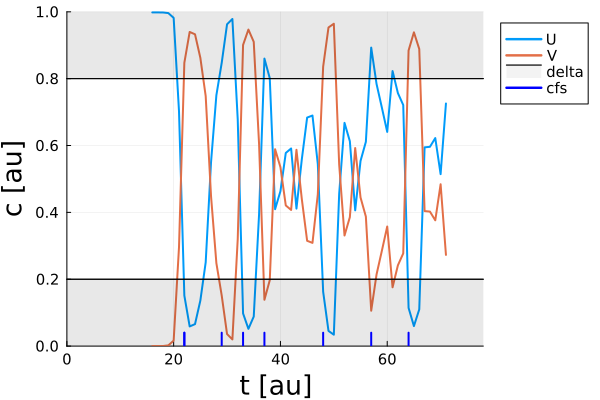

"D:\\data\\plots\\paper\\cfs_example.svg"

In [9]:

simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")
folder = "D:/data/paper25/cell_div_300/sorting/timecourse/q/q/"

path = folder*"q_0.1_rep_1.jld2"
test_data = deserialize(path)
u = transform_data_to_matrix(test_data[2].u)
v = transform_data_to_matrix(test_data[2].v)
delta=0.2

switches_array = []
index_array = []
for cell_id in range(1,length(u[1,:]))
    switches,indeces = calculate_switches_delta_index(u[:,cell_id],v[:,cell_id],delta)
    push!(switches_array,switches)
    push!(index_array,indeces)
end



cmap = cgrad(:bam10,10,categorical  =true, rev = true)
p = plot(u[:,findmax(switches_array)[2]],label="U",xlabel="t [au]",ylabel="c [au]",title="",lw=2,legend=:outertopright,
    xtickfontsize=10,ytickfontsize=10,xguidefontsize=18,yguidefontsize=18,legendfontsize=10,titlefontsize=18,markersize=6,xlims=(0,78))
plot!(p,v[:,findmax(switches_array)[2]],label="V",yrange=(0,1),lw=2)
hline!(p,[delta,delta],label="delta",color="black",fillrange=[0,0],fillalpha=0.05)
hline!(p,[1-delta,1-delta],label="",color="black",fillrange=[1,1],fillalpha=0.05)

xpos = index_array[findmax(switches_array)[2]]
y1, y2 = 0, 0.04          # x end points for horizontal lines
plot!(hcat(xpos,xpos)',[y1; y2], lw=2, lc=:blue,label="")
plot!(hcat(xpos[1],xpos[1])',[y1; y2], lw=2, lc=:blue,label="cfs")

outpath = "D:/data/plots/paper/"
display(p)
savefig(p,outpath*"cfs_example.pdf")
savefig(p,outpath*"cfs_example.svg")

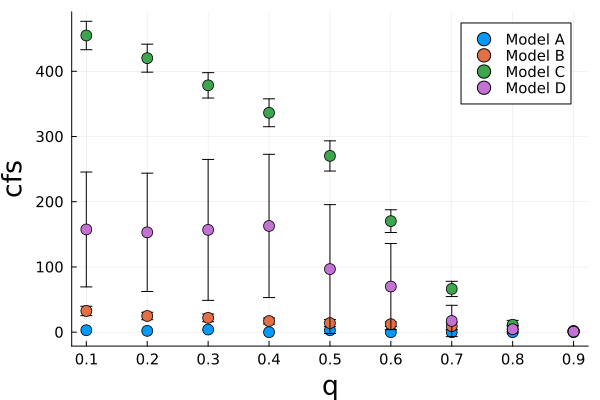

"D:\\data\\plots\\paper\\mean_total_cfs_per_q.pdf"

In [ ]:
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")

folder_model_a = "D:/data/paper25/ss_3d/timecourse/q/q/"
replicates = 50
delta=0.2
values = range(0.1,step=0.1,stop=0.9)

switches_matrix = 1:replicates

for value in values
    switches_reps = []
    for r in range(1,replicates)
        path = folder_model_a*"q_"*string(value)*"_rep_"*string(r)*"_tdc.jld2"
        test_data = deserialize(path)
        u = transform_data_to_matrix(test_data.u)
        v = transform_data_to_matrix(test_data.v)
        switches_array=[]
        for cell_id in range(1,length(u[1,:]))
            push!(switches_array,calculate_switches_delta(u[:,cell_id],v[:,cell_id],delta))
        end
        push!(switches_reps,sum(switches_array))
    end
    switches_matrix = hcat(switches_matrix,switches_reps)
end
switches_df = DataFrame(switches_matrix, string.(["reps",values...]))
select!(switches_df, Not(:reps))
p = scatter(values,mean.(eachcol(switches_df)),label="Model A",ylabel="cfs",xlabel="q",title="",xticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    xtickfontsize=10,ytickfontsize=10,xguidefontsize=18,yguidefontsize=18,legendfontsize=10,titlefontsize=18,markersize=6)


folder_model_b = "D:/data/paper25/cell_div_300/timecourse/no_sorting/q/q/"
folder_model_c = "D:/data/paper25/cell_div_300/timecourse/sorting/q/q/"
folder_model_d = "D:/data/paper25/set_to_zero/timecourse/q/q/"
for (k,model) in enumerate([folder_model_b,folder_model_c,folder_model_d])
    switches_matrix = 1:replicates
    for value in values
        switches_reps = []
        for r in range(1,replicates)
            path = model*"q_"*string(value)*"_rep_"*string(r)*".jld2"
            test_data = deserialize(path)
            u = transform_data_to_matrix(test_data[2].u)
            v = transform_data_to_matrix(test_data[2].v)
            switches_array=[]
            for cell_id in range(1,length(u[1,:]))
                push!(switches_array,calculate_switches_delta(u[:,cell_id],v[:,cell_id],delta))
            end
            push!(switches_reps,sum(switches_array))
        end
        switches_matrix = hcat(switches_matrix,switches_reps)
    end

    switches_df = DataFrame(switches_matrix, string.(["reps",values...]))
    select!(switches_df, Not(:reps))
    scatter!(p,values,mean.(eachcol(switches_df)),label=["Model B","Model C","Model D"][k],markersize=6,yerror=std.(eachcol(switches_df)))
end
display(p)
outpath = "D:/data/plots/paper/"
#savefig(p,outpath*"mean_total_cfs_per_q.svg")
#savefig(p,outpath*"mean_total_cfs_per_q.pdf")


## Cell fate ratio for all models

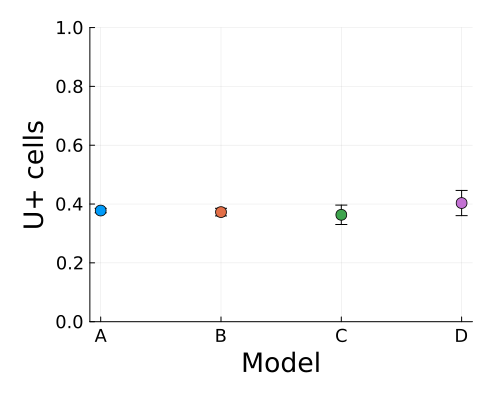

In [ ]:
par = "q"
values = range(0.1,step=0.1,stop=0.9)
replicates = 30
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")


#full_path_1 = "D:/data/paper25/ss/cells_300/q/q/"
full_path_1 = "D:/data/paper25/ss_3d/timecourse/q/q/" 

full_path_2 = "D:/data/paper25/cell_div_300/timecourse/no_sorting/q/q/"
full_path_3 = "D:/data/paper25/cell_div_300/timecourse/sorting/q/q/"

path_list = [full_path_1,full_path_2,full_path_3]
df_list = []
for full_path in path_list
    q_df = DataFrame()
    for k in values
        #str_k = replace(string(k), "." => "_")
        str_k = string(k)
        morans = zeros(Union{Missing,Float64},replicates)
        for i in range(1,replicates)
            try
            test_ms = deserialize(full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")
            
            
            if typeof(test_ms) == Cell_struct
    
                morans[i] = calculate_ratio(test_ms, simulation_type_tup)
            else

                morans[i] = calculate_ratio(test_ms[1], simulation_type_tup)
            end

            catch e
                #println("Error: ", e)
                println("Could not load file: ", full_path*"q_"*str_k*"_rep_"*string(i)*".jld2")
                continue
            
            
            finally
                continue
            end
        end
        q_df[!, string(k)] = morans
    end

    push!(df_list, q_df)
end

x_values = [1,2,3,4]
x_labels = ["A","B","C","D"]
p = plot(xticks=(x_values,x_labels),legend = :topleft,size=(500,400),margin=5mm,ylims=(0,1)
,xtickfontsize=12,ytickfontsize=12,xguidefontsize=18,yguidefontsize=18,legendfontsize=12,ylabel="U+ cells",xlabel="Model")

c = [palette(:tab10)[1],palette(:tab10)[2]]
labels=["Model A","Model B","Model C"]
for i in range(1,length(df_list))
    for c ∈ eachcol(df_list[i])
        replace!(c, NaN => missing)
    end
    s = std(stack(df_list[i]).value)
    m = mean(stack(df_list[i]).value)
    scatter!(p,(x_values[i],m),label="",markersize=6,yerror=s)

end


par = "q"
values = range(4,10)
q_values = range(0.1,step=0.1,stop=0.9)
replicates = 50        
simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")
x_names = ["10-"*string(x) for x in values]
path_part_1 = "D:/data/paper25/set_to_zero/tol_"
path_part_2 = "/q/q/"

outpath = "D:/data/plots/paper/"
q_df = DataFrame()
for q_value in q_values
    q_list = []


    for k in values
     
        str_k = string(k)

        full_path = path_part_1 *string(k)*path_part_2
        morans = zeros(Union{Missing,Float64},replicates)
        for i in range(1,replicates)
            try
            test_ms = deserialize(full_path*"q_"*string(q_value)*"_rep_"*string(i)*".jld2")
    

            morans[i] = calculate_ratio(test_ms[1], simulation_type_tup)

            catch e
                #println("Error: ", e)
                println("Could not load file: ", full_path*par*"_"*str_k*"_rep_"*string(i)*".jld2")
                continue
            
            
            finally
                continue
            end
        end
        push!(q_list,morans)
    end
    q_df[!, string(q_value)] = q_list
end
M = cat(Matrix(q_df)...,dims=3)


s = std(M)
m = mean(M)
scatter!(p,(x_values[4],m),label="",markersize=6,yerror=s)
#savefig(p,outpath*"cf_ratio.pdf")
#savefig(p,outpath*"cf_ratio.svg")
display(p)

## Force example


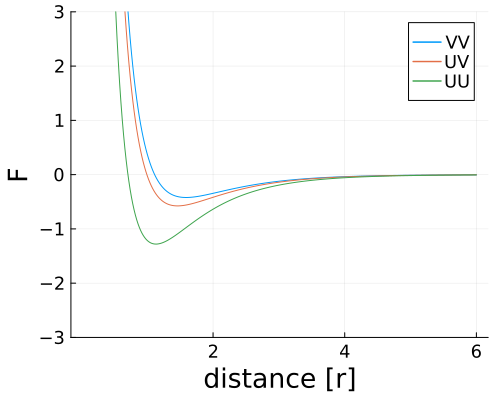

In [3]:
cells_dict = Dict(
    "xy" => ([1.0 0.0; -1.0 0.0]),
    "r" => [0.5, 0.5],
    "u" => [0.0, 0.0],
    "v" => [1.0, 1.0],
)

simulation_type_tup = read_sim_options(path_project*"simulation_options.txt")
par = CSV.File(path_project*"new_parameter.csv") |> Dict
par["beta"] = 1.0
cell_ms = Cell_struct(cells_dict)

p = plot(xticks=([1,2,3],["2","4","6"]),size=(500,400),
    ylim=(-3,3),ylabel="F",xlabel="distance [r]",xtickfontsize=12,ytickfontsize=12,xguidefontsize=18,yguidefontsize=18,legendfontsize=12)
u_values = [[0.0, 0.0],[0.0, 1.0],[1.0, 1.0]]
v_values = [[1.0, 1.0],[1.0, 0.0],[0.0, 0.0]]
label_array =["VV","UV","UU"]
for k in [1,2,3]
    cell_ms.u = u_values[k]
    cell_ms.v = v_values[k]
    F_array =[]
    dist_range = range(0.01, 3.0, step=0.01)
    for d in dist_range
        distance = [0.0 d;d 0.0]
        r_pairwise = cell_ms.r' .+ cell_ms.r

        x_pairwise = cell_ms.xy[:,1]' .- cell_ms.xy[:,1]
        y_pairwise = cell_ms.xy[:,2]' .- cell_ms.xy[:,2]

        # calculate affinity
        eta_a = ones(length(cell_ms.v),length(cell_ms.v))
        for k in range(1,length(cell_ms.r))
            for i in range(1,length(cell_ms.r))
                eta_a[k,i] = ((cell_ms.u[k] + cell_ms.v[k]) * (cell_ms.u[i] + cell_ms.v[i]))/(cell_ms.v[k] + cell_ms.v[i] + par["beta"]) + 1/par["beta"]
            end
        end
        # Absolute values of forces according to Morse potential
        F = par["F0"]*2*par["alpha"]*(exp.(-2*par["alpha"]*(distance-r_pairwise*par["sigma"])) - eta_a .* exp.(-par["alpha"]*(distance-r_pairwise*par["sigma"])))
        distance[diagind(distance)].=Inf32

        # x- and y-direction of forces
        Fx = F.*(x_pairwise)./distance
        Fy = F.*(y_pairwise)./distance
        push!(F_array,Fx[1,2])
    end
    plot!(p,dist_range,-F_array,label=label_array[k])
end
outpath = "D:/data/plots/paper/"
#savefig(p,outpath*"forces_example.pdf")
p

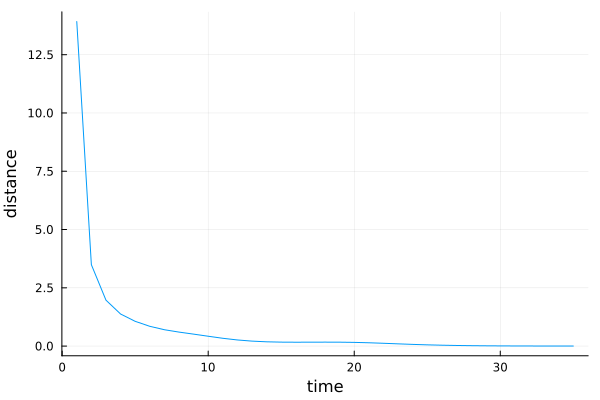

In [6]:
file_path = "D:/data/paper25/ss_3d/timecourse/q/q/q_0.9_rep_10_tdc.jld2"
test = deserialize(file_path)

file_path = "D:/data/paper25/ss_3d/timecourse/q/q/q_0.9_rep_10.jld2"
last = deserialize(file_path)
push!(test.u,last.u)
push!(test.v,last.v)

error = zeros(Float64,length(test.v))  
for i in range(2,length(error))
    error[i] = norm(test.u[i] - test.u[i-1]) + norm(test.v[i] - test.v[i-1])
end
plot(error[2:end],ylabel="distance",xlabel="time",label="",title = "")